# SP・PB・APのカテゴリ別売上を月と季節で比較

## 目的とデータ

SPの平均注文額向上と、PB・APの販促仮説を考えるため、3州のカテゴリ別の注文数・GMV・注文額を時系列で確認する。入力はAthenaの[月×州×カテゴリ集計SQL](../sql/athena/20_monthly_category_sales_by_state.sql)を実行して保存した`../data/monthly_category_sales_by_state.csv`と、既存の`../data/sales_baseline_by_month_state.csv`。

比較するカテゴリは`bed_bath_table`、`health_beauty`、`watches_gifts`、`computers_accessories`。APで1注文の`computers`などは推移図から外す。元CSVには全カテゴリを残し、集計の照合に使う。

**指標の違い**

- カテゴリ注文数：そのカテゴリの商品を含む注文数。同じ注文が複数カテゴリに含まれる場合、カテゴリごとに数える。
- カテゴリGMV：そのカテゴリの商品の価格合計。送料は含まない。
- カテゴリ注文のAOV：そのカテゴリを含む注文の**注文全体のGMV**合計 ÷ カテゴリ注文数。複数カテゴリを含む注文の全額が各カテゴリに入るため、カテゴリ間では足せない。
- **平均注文額へのカテゴリ構成額**：カテゴリGMV ÷ その州・期間の全注文数。全カテゴリの構成額を足すと、その州・期間の平均注文額になる。3州のGMV規模が違うため、推移図の縦軸にはこの指標を使う。

ブラジルの四季は分析上、夏＝12～2月、秋＝3～5月、冬＝6～8月、春＝9～11月と定義する。12月は翌年の夏に含める。比較には2017年3月～2018年8月を使い、3か月がそろう6季節を作る。2016年の初期月は注文数が少なく、季節比較から外す。


In [1]:
import sys
from pathlib import Path

# Notebookをどの作業フォルダから開いてもsrc/を読み込めるようにする。
PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import display

from src.analysis_plots import (
    plot_category_trends,
    plot_sp_category_orders_and_gmv,
    plot_sp_category_trends,
)
from src.project_paths import DATA_DIR, IMAGE_DIR
from src.sales_metrics import (
    category_plot_data,
    monthly_category_metrics,
    seasonal_category_metrics,
)

df_month_category = pd.read_csv(DATA_DIR / "monthly_category_sales_by_state.csv")
df_baseline = pd.read_csv(DATA_DIR / "sales_baseline_by_month_state.csv")
print("月×州×カテゴリ:", df_month_category.shape)
display(df_month_category.head())
display(df_month_category.isna().sum())

月×州×カテゴリ: (1488, 6)


,purchase_month,customer_state,product_category,category_order_count,category_gmv,category_order_total_gmv
0,2016-09,SP,health_beauty,1,134.97,134.97
1,2016-10,PB,toys,1,49.90,49.90
2,2016-10,SP,furniture_decor,17,1772.41,1772.41
3,2016-10,SP,perfumery,10,1520.90,1520.90
4,2016-10,SP,toys,6,1086.58,1086.58


purchase_month              0
customer_state              0
product_category            0
category_order_count        0
category_gmv                0
category_order_total_gmv    0
dtype: int64

In [2]:
# 州全体の注文数を結合し、カテゴリGMVが月×州の基準値と一致するか確認する。
target_states = ["SP", "PB", "AP"]
monthly, state_month, reconciliation = monthly_category_metrics(
    df_month_category, df_baseline, target_states
)
display(reconciliation.tail(12).round({
    "category_gmv_sum": 2, "state_gmv": 2, "gmv_difference": 2,
}))
print("GMV差の絶対値の最大:", reconciliation["gmv_difference"].abs().max())

,month_start,customer_state,category_gmv_sum,state_gmv,gmv_difference
49,2018-05-01,AP,955.68,955.68,0.0
50,2018-05-01,PB,4860.44,4860.44,0.0
51,2018-05-01,SP,424628.36,424628.36,0.0
52,2018-06-01,AP,167.48,167.48,0.0
53,2018-06-01,PB,12993.83,12993.83,0.0
54,2018-06-01,SP,340596.94,340596.94,-0.0
55,2018-07-01,AP,1350.84,1350.84,0.0
56,2018-07-01,PB,15188.68,15188.68,0.0
57,2018-07-01,SP,321647.25,321647.25,-0.0
58,2018-08-01,AP,194.00,194.00,0.0


GMV差の絶対値の最大: 5.529727786779404e-10


## 季節の作り方

月ごとの注文は一つの季節にだけ入る。したがって、季節のカテゴリ注文数・カテゴリGMV・州の注文数は、対応する3か月の**合計**を使う。AOVは月別AOVの単純平均にせず、季節全体の金額合計を注文数合計で割り直す。


In [3]:
# 期間を決め、3か月の分子・分母を合算してから季節指標を計算する。
analysis_start = pd.Timestamp("2017-03-01")
analysis_end = pd.Timestamp("2018-08-01")
monthly_period, state_month_period, seasonal, season_state = seasonal_category_metrics(
    monthly, state_month, analysis_start, analysis_end
)
display(season_state.sort_values(
    ["season_start", "customer_state"]
).round({"state_gmv": 2}))

,season_start,customer_state,state_orders,state_gmv
0,2017-03-01,AP,7,1524.68
1,2017-03-01,PB,53,10154.58
2,2017-03-01,SP,3202,426706.99
3,2017-06-01,AP,6,802.39
4,2017-06-01,PB,64,12297.75
5,2017-06-01,SP,4492,539010.99
6,2017-09-01,AP,9,2468.33
7,2017-09-01,PB,80,19623.48
8,2017-09-01,SP,6198,782045.56
9,2017-12-01,AP,17,4003.47


## 月別・季節別の比較表

表では、カテゴリ注文数、カテゴリGMV、カテゴリ注文のAOV、平均注文額への構成額を確認する。APは注文数が少ないため、特に月別の値は数件の注文で大きく変わりうる。グラフを読む際にも、同じ期間の州全体の注文数を確認する。


In [4]:
focus_categories = [
    "bed_bath_table",
    "health_beauty",
    "watches_gifts",
    "computers_accessories",
]
columns_to_show = [
    "customer_state", "product_category", "state_orders",
    "category_order_count", "category_gmv",
    "category_order_aov", "aov_part",
]

# まず直近の月と季節を表示する。期間を変更しても同じ列で比較できる。
latest_month = monthly_period["month_start"].max()
latest_season = seasonal["season_start"].max()
print("月別:", latest_month.strftime("%Y-%m"))
display(
    monthly_period.loc[
        (monthly_period["month_start"] == latest_month)
        & monthly_period["product_category"].isin(focus_categories),
        columns_to_show,
    ].sort_values(["product_category", "customer_state"]).round(2)
)
print("季節別:", latest_season.strftime("%Y-%m"))
display(
    seasonal.loc[
        (seasonal["season_start"] == latest_season)
        & seasonal["product_category"].isin(focus_categories),
        columns_to_show,
    ].sort_values(["product_category", "customer_state"]).round(2)
)


月別: 2018-08


,customer_state,product_category,state_orders,category_order_count,category_gmv,category_order_aov,aov_part
1425,SP,bed_bath_table,3164,320,37305.79,117.66,11.79
1410,AP,computers_accessories,2,1,99.00,99.00,49.50
1417,PB,computers_accessories,28,4,638.70,159.68,22.81
1430,SP,computers_accessories,3164,179,17369.38,97.26,5.49
1416,PB,health_beauty,28,4,770.65,192.66,27.52
1424,SP,health_beauty,3164,370,49676.60,135.08,15.70
1413,PB,watches_gifts,28,3,1194.91,398.30,42.68
1427,SP,watches_gifts,3164,168,26245.44,156.81,8.30


季節別: 2018-06


,customer_state,product_category,state_orders,category_order_count,category_gmv,category_order_aov,aov_part
506,PB,bed_bath_table,107,4,281.69,70.42,2.63
539,SP,bed_bath_table,8617,932,102152.61,110.86,11.85
497,AP,computers_accessories,10,1,99.00,99.00,9.90
509,PB,computers_accessories,107,12,1434.80,119.57,13.41
546,SP,computers_accessories,8617,484,52168.36,107.99,6.05
500,AP,health_beauty,10,1,122.99,122.99,12.30
517,PB,health_beauty,107,18,4193.32,232.96,39.19
573,SP,health_beauty,8617,1049,126922.31,122.27,14.73
503,AP,watches_gifts,10,1,78.00,78.00,7.80
531,PB,watches_gifts,107,11,6246.81,567.89,58.38


In [5]:
# 表を詳しく読むカテゴリを1つ選ぶ。名前を変えて同じ集計を確認できる。
selected_category = "health_beauty"

# カテゴリの注文がなかった月・州は、この表には行がない。
# 後の推移図では、州の注文があれば構成額0として表示する。
monthly_detail = monthly_period.loc[
    monthly_period["product_category"] == selected_category,
    ["purchase_month", "customer_state", "state_orders",
     "category_order_count", "category_gmv",
     "category_order_aov", "aov_part"],
].sort_values(["purchase_month", "customer_state"])
seasonal_detail = seasonal.loc[
    seasonal["product_category"] == selected_category,
    ["season_label", "season_start", "customer_state", "state_orders",
     "category_order_count", "category_gmv",
     "category_order_aov", "aov_part"],
].sort_values(["season_start", "customer_state"])

print("月別:", selected_category)
display(monthly_detail.round(2))
print("季節別:", selected_category)
display(seasonal_detail.drop(columns="season_start").round(2))


月別: health_beauty


,purchase_month,customer_state,state_orders,category_order_count,category_gmv,category_order_aov,aov_part
124,2017-03,PB,16,2,711.90,355.95,44.49
138,2017-03,SP,966,71,9434.53,132.88,9.77
183,2017-04,PB,20,2,496.49,248.24,24.82
198,2017-04,SP,873,62,8465.85,137.09,9.70
246,2017-05,AP,4,2,245.90,122.95,61.48
249,2017-05,PB,17,3,424.99,141.66,25.00
263,2017-05,SP,1363,107,11745.98,109.78,8.62
313,2017-06,PB,22,3,1658.00,552.67,75.36
334,2017-06,SP,1284,90,10050.44,112.16,7.83
375,2017-07,AP,1,1,259.90,259.90,259.90


季節別: health_beauty


,season_label,customer_state,state_orders,category_order_count,category_gmv,category_order_aov,aov_part
5,2017 Autumn,AP,7,2,245.90,122.95,35.13
19,2017 Autumn,PB,53,7,1633.38,233.34,30.82
66,2017 Autumn,SP,3202,240,29646.36,123.67,9.26
93,2017 Winter,AP,6,1,259.90,259.90,43.32
108,2017 Winter,PB,64,6,1878.90,313.15,29.36
156,2017 Winter,SP,4492,336,32975.36,98.39,7.34
187,2017 Spring,AP,9,3,234.89,78.30,26.10
204,2017 Spring,PB,80,14,2913.51,208.11,36.42
261,2017 Spring,SP,6198,439,60296.28,137.71,9.73
310,2018 Summer,PB,103,11,1577.15,143.38,15.31


## 州ごとに色を固定して月別・季節別を比較する

月別と季節別をそれぞれ**1枚の図**にまとめ、各カテゴリの小図でSP・PB・APを同じ目盛り上に描く。SPは青、PBは橙、APは緑に固定し、線種と記号でも州を区別する。**縦軸の範囲はカテゴリごとに異なる**ため、小図をまたいで線の高さを直接比較しない。月×州でそのカテゴリの注文がなければ、平均注文額への構成額は0。州全体の注文もなければ値は表示しない。


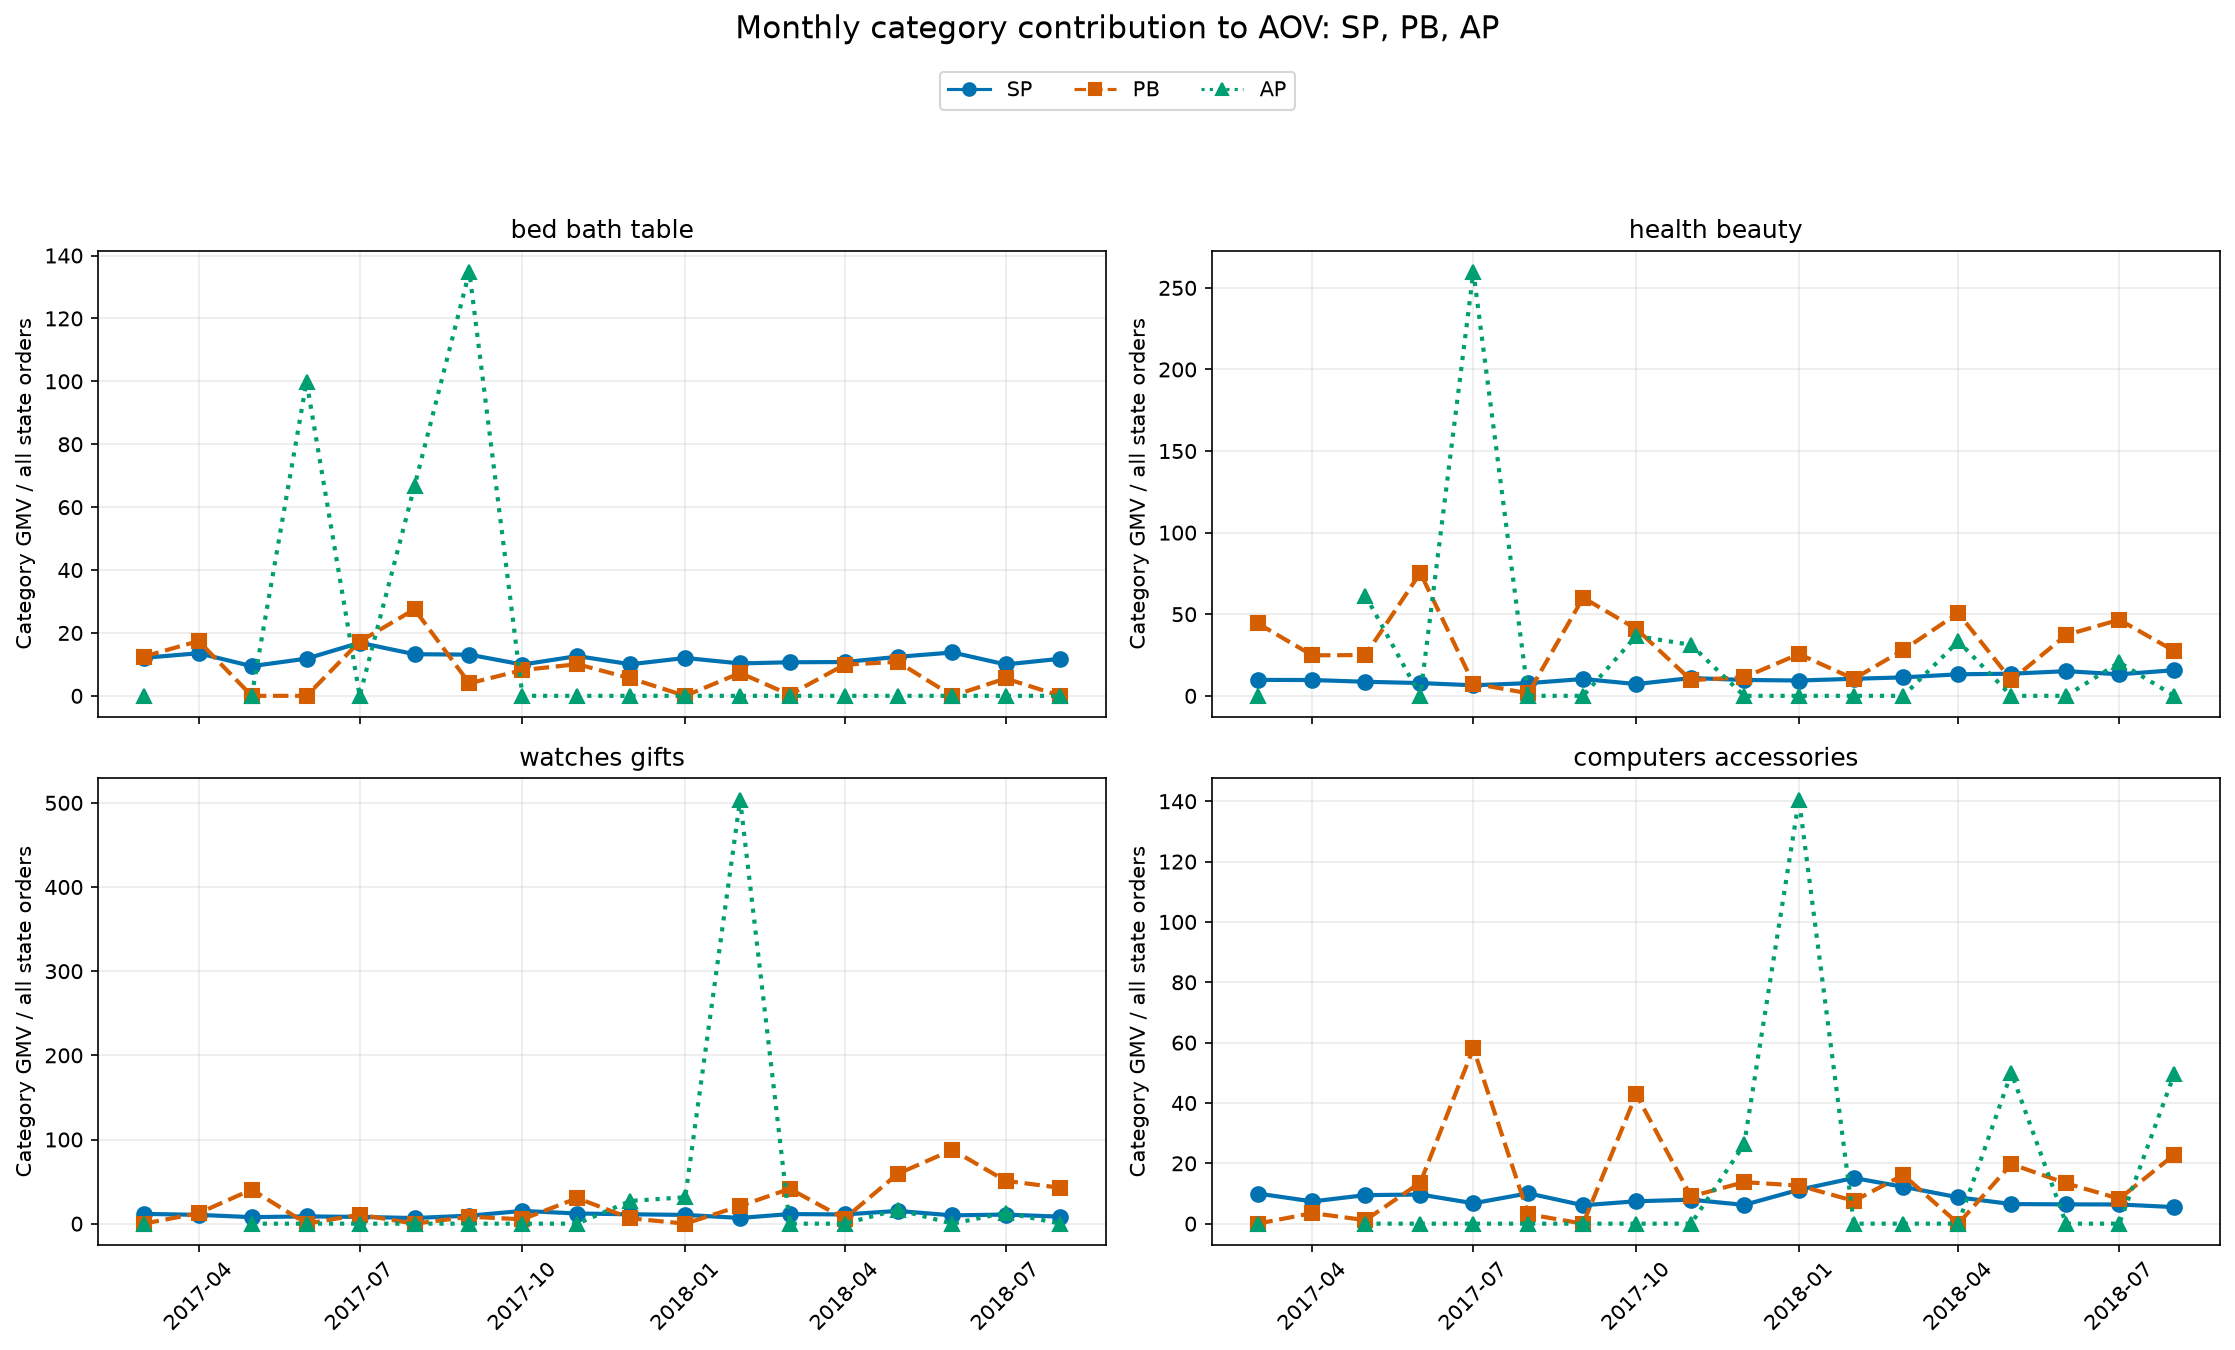

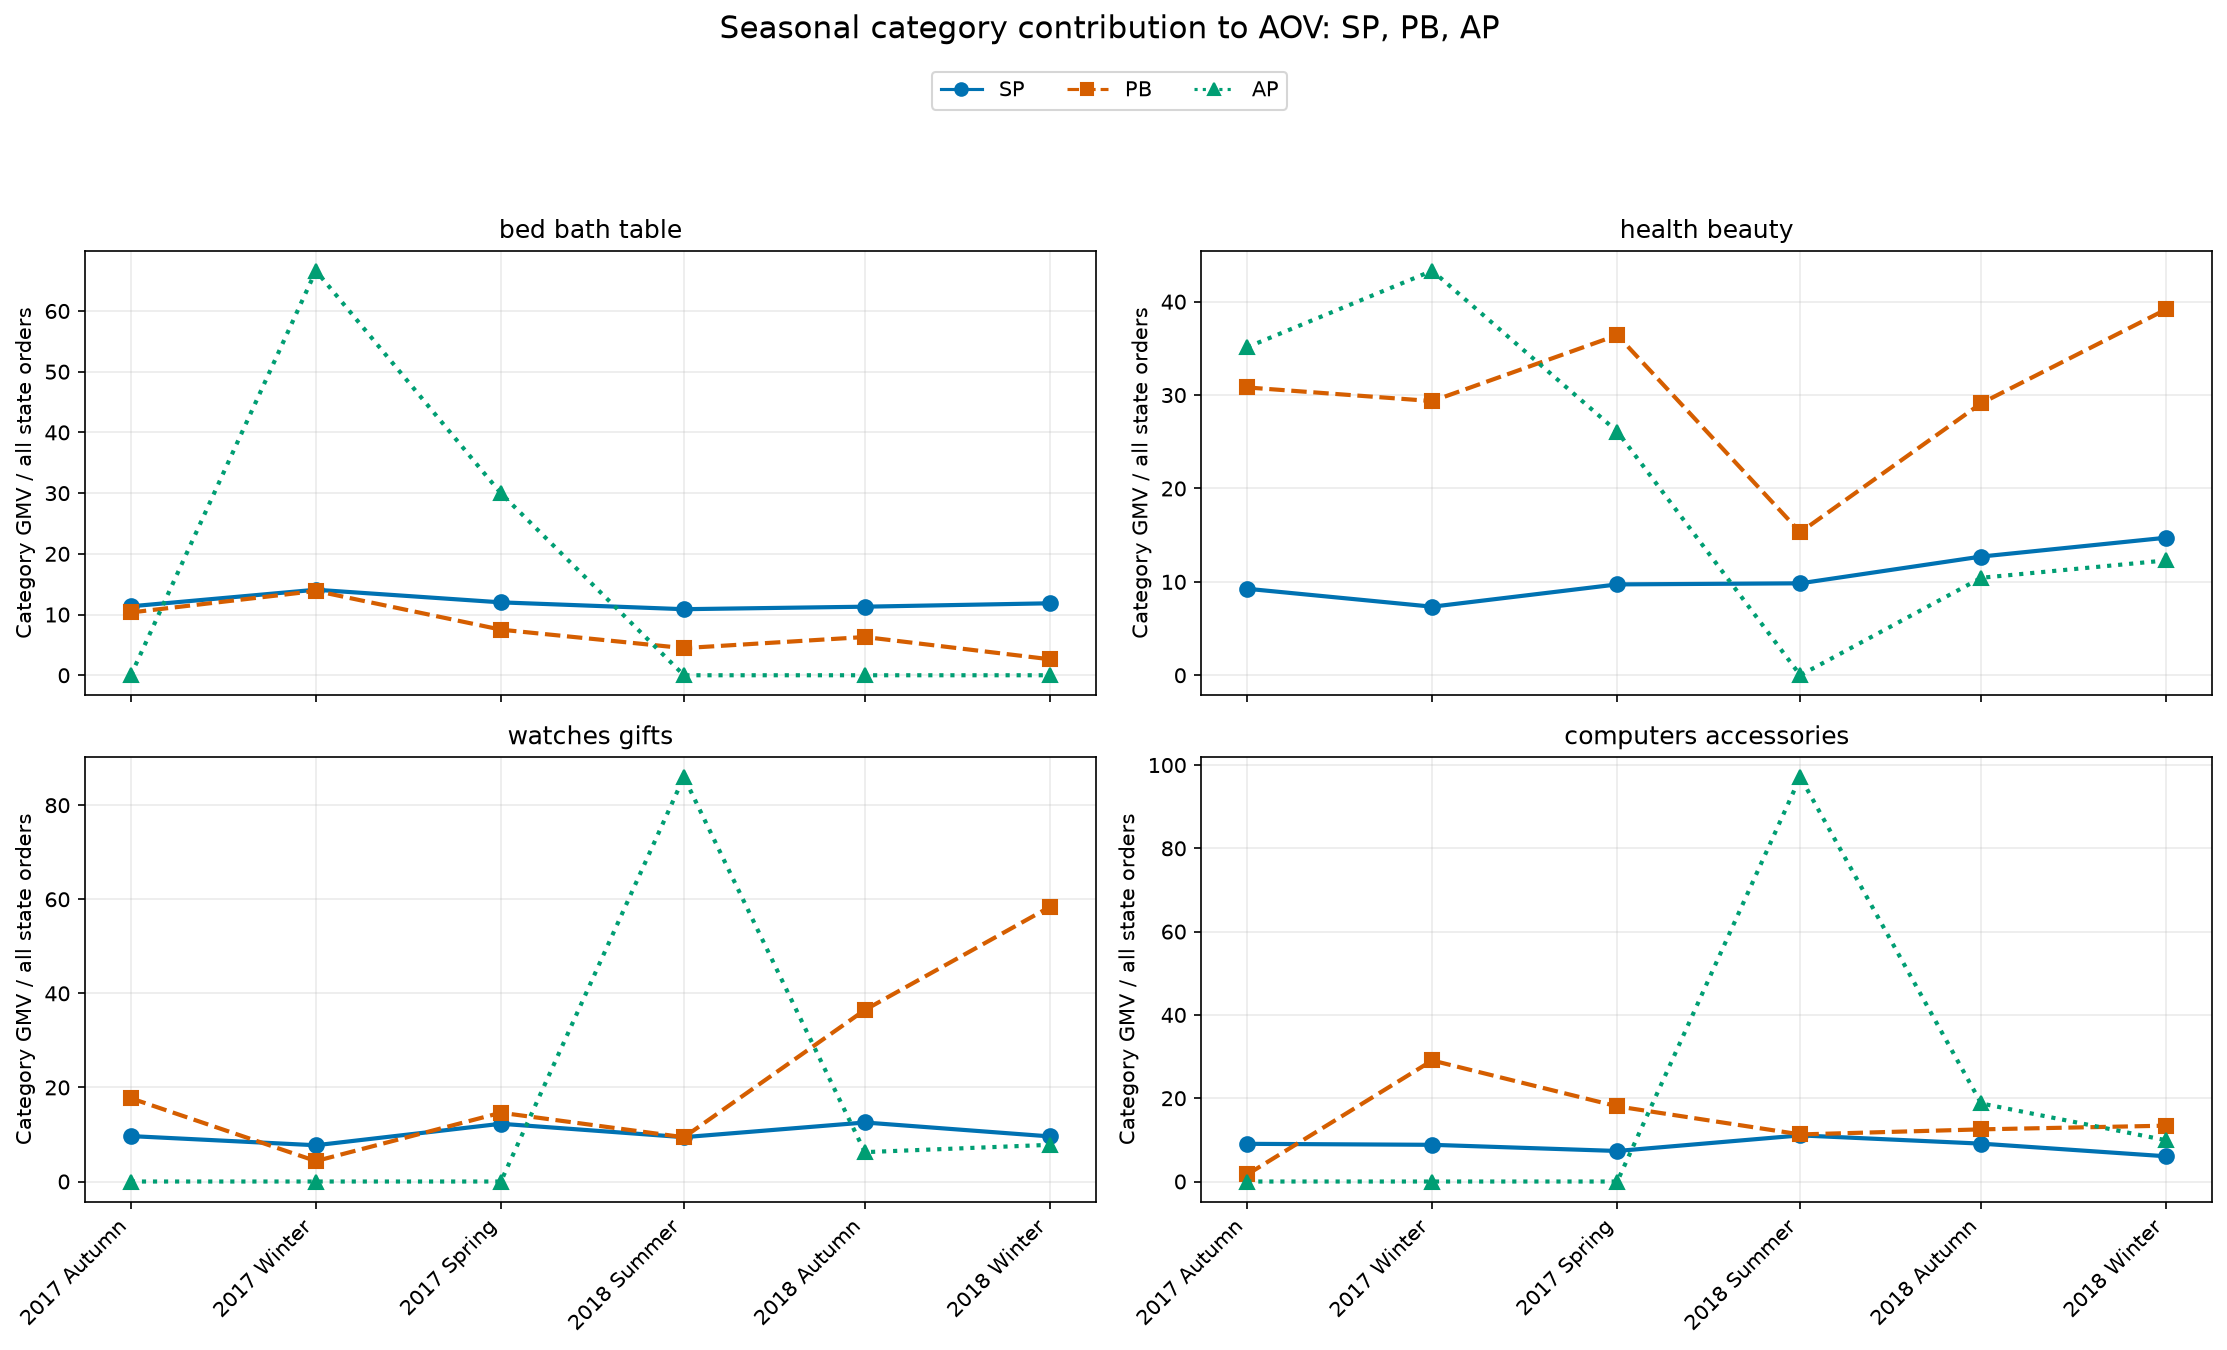

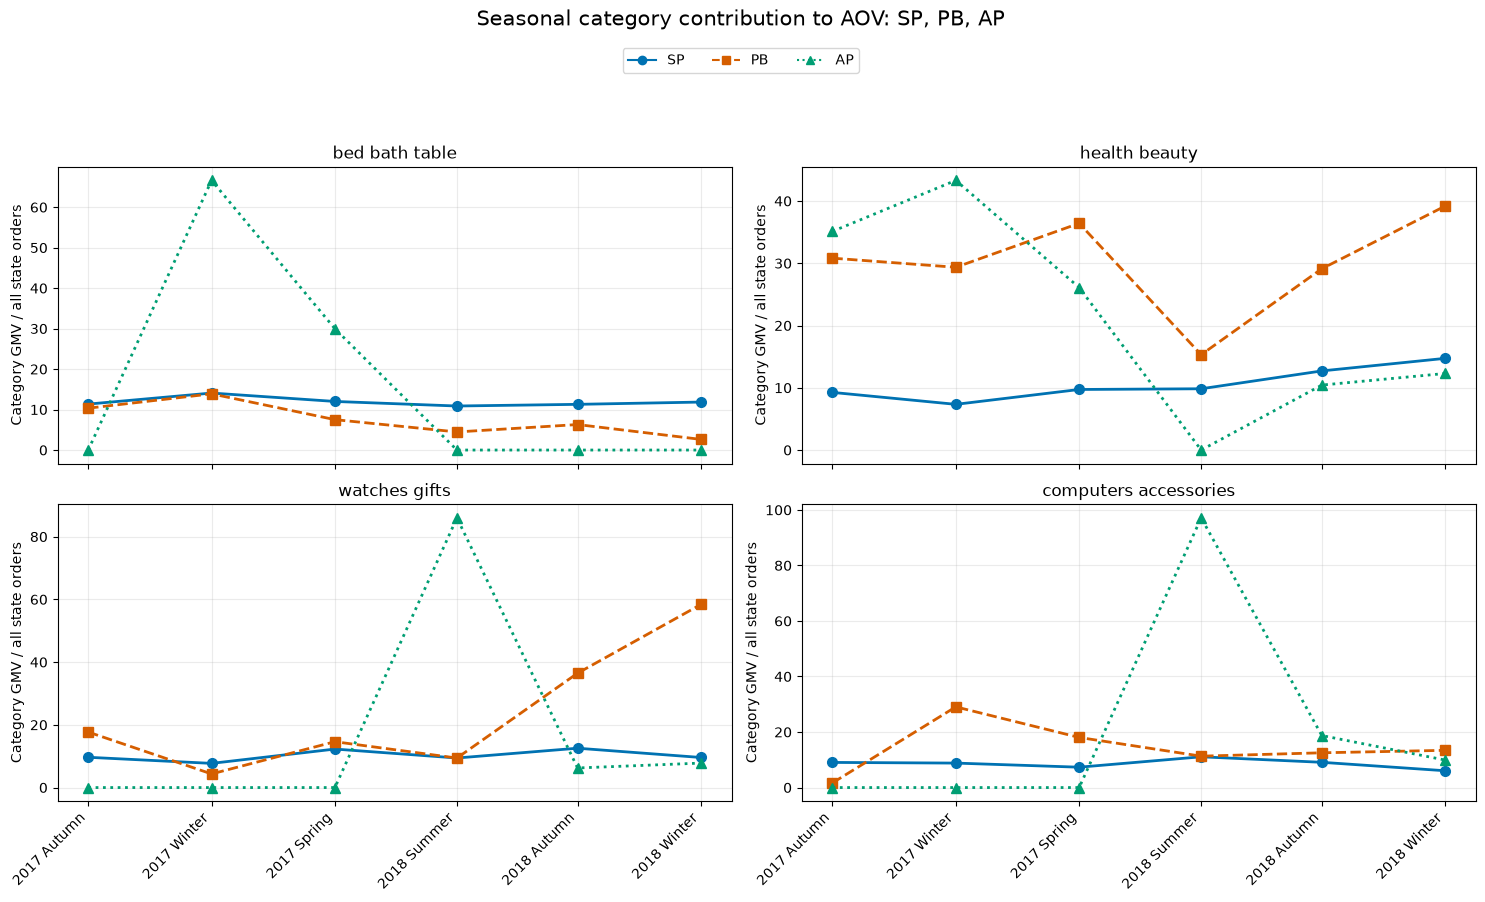

In [6]:
# 月別と季節別の州×カテゴリをそろえ、同じ州を同じ色で描く。
monthly_plot = category_plot_data(
    state_month_period.rename(columns={"month_start": "period_start"}),
    monthly_period.rename(columns={"month_start": "period_start"}),
    "period_start", pd.date_range(analysis_start, analysis_end, freq="MS"),
    target_states, focus_categories,
)
seasonal_plot = category_plot_data(
    season_state, seasonal, "season_start",
    pd.DatetimeIndex(sorted(season_state["season_start"].unique())),
    target_states, focus_categories,
)
plot_category_trends(
    monthly_plot, "period_start", focus_categories, target_states,
    "Monthly category contribution to AOV: SP, PB, AP",
    IMAGE_DIR / "Monthly_Category_AOV_Contribution_SP_PB_AP.png",
)
plot_category_trends(
    seasonal_plot, "season_start", focus_categories, target_states,
    "Seasonal category contribution to AOV: SP, PB, AP",
    IMAGE_DIR / "Seasonal_Category_AOV_Contribution_SP_PB_AP.png",
)

## SP州のカテゴリ構成額を拡大して見る

APは月の州全体の注文数が少なく、1件の高額注文で縦軸が大きく伸びる。SPの4カテゴリの推移を読みやすくするため、SPだけを月別と季節別で並べる。この図ではカテゴリごとに色を変え、線種と記号でも区別する。縦軸は「カテゴリGMV ÷ 州全体の注文数」であり、カテゴリを含む注文だけのAOVではない。


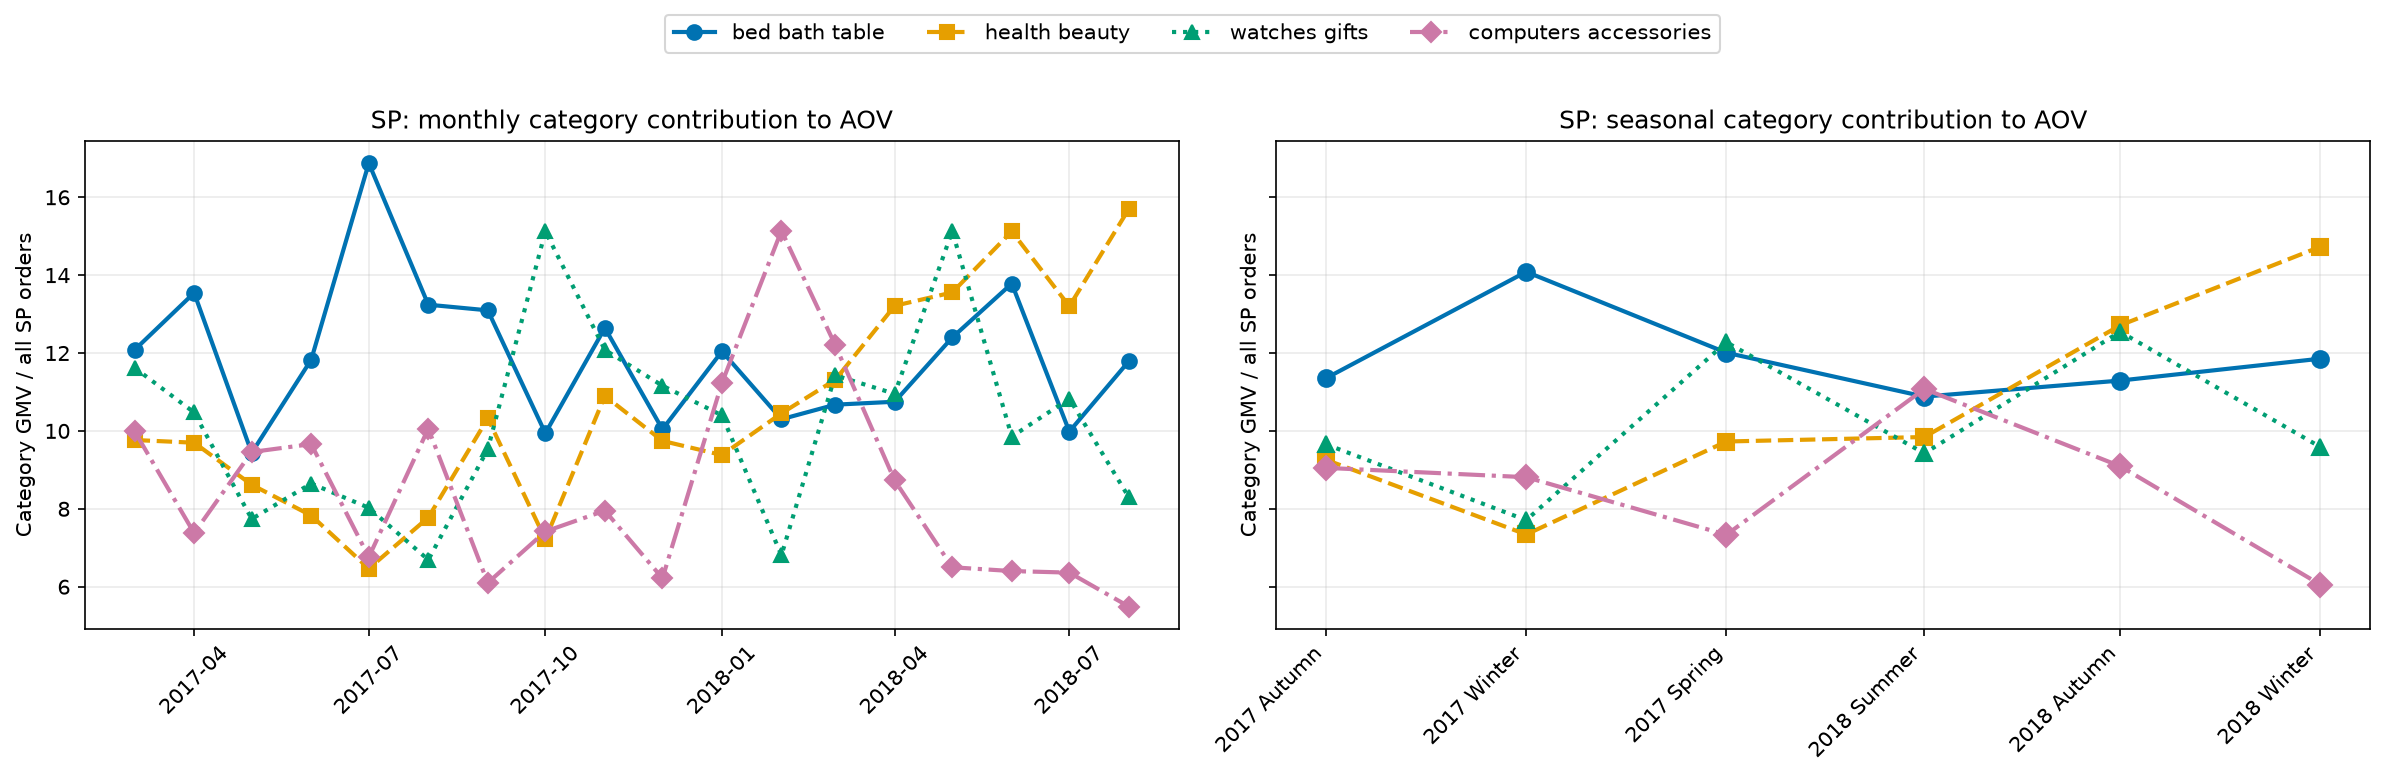

In [7]:
# SPを拡大して表示。カテゴリを色・線種・記号で区別する。
sp_figure = plot_sp_category_trends(
    monthly_plot, seasonal_plot, focus_categories,
    IMAGE_DIR / "SP_Category_AOV_Contribution_Monthly_Seasonal.png",
)


## 次の分析：SPで変化した要因を分けて見る

まず図で差が見えた`health_beauty`を含む4カテゴリについて、2017年冬と2018年冬を比較する。冬は両年とも6～8月の3か月。**カテゴリGMV ÷ 州全体の注文数**は、**カテゴリ注文数 ÷ 州全体の注文数**と**カテゴリGMV ÷ カテゴリ注文数**の積に等しい。これにより、カテゴリを含む注文の割合と、その注文あたりのカテゴリGMVを分けて確認できる。後者の変化だけでは、同じカテゴリ内の商品構成・単価・数量のどれが変わったかは分からない。


In [8]:
# SPの同じ季節を2年で比較し、注文規模の増加とカテゴリの変化を分ける。
winters = [pd.Timestamp("2017-06-01"), pd.Timestamp("2018-06-01")]
sp_winter = seasonal.loc[
    (seasonal["customer_state"] == "SP")
    & seasonal["season_start"].isin(winters)
    & seasonal["product_category"].isin(focus_categories)
].copy()
sp_winter["category_order_rate_pct"] = (
    sp_winter["category_order_count"] / sp_winter["state_orders"] * 100
)

# 等式：AOV構成額 = カテゴリ注文率 × カテゴリ注文あたりGMV。
# 表の注文率は%なので、計算時だけ100で割る。
sp_winter["aov_part_from_factors"] = (
    sp_winter["category_order_rate_pct"] / 100
    * sp_winter["category_gmv_per_category_order"]
)
columns = [
    "season_label", "product_category", "state_orders",
    "category_order_count", "category_order_rate_pct", "category_gmv",
    "category_gmv_per_category_order", "aov_part", "aov_part_from_factors",
]
display(sp_winter[columns].sort_values(
    ["product_category", "season_label"]
).round(2))


,season_label,product_category,state_orders,category_order_count,category_order_rate_pct,category_gmv,category_gmv_per_category_order,aov_part,aov_part_from_factors
125,2017 Winter,bed_bath_table,4492,563,12.53,63273.27,112.39,14.09,14.09
539,2018 Winter,bed_bath_table,8617,932,10.82,102152.61,109.61,11.85,11.85
133,2017 Winter,computers_accessories,4492,291,6.48,39582.72,136.02,8.81,8.81
546,2018 Winter,computers_accessories,8617,484,5.62,52168.36,107.79,6.05,6.05
156,2017 Winter,health_beauty,4492,336,7.48,32975.36,98.14,7.34,7.34
573,2018 Winter,health_beauty,8617,1049,12.17,126922.31,120.99,14.73,14.73
183,2017 Winter,watches_gifts,4492,174,3.87,34627.62,199.01,7.71,7.71
600,2018 Winter,watches_gifts,8617,514,5.96,82620.28,160.74,9.59,9.59


### 表から読むこと

- `health_beauty`はカテゴリ注文率とカテゴリ注文あたりGMVがともに上がった。この2つが州AOVへの構成額の上昇に対応する。
- `bed_bath_table`と`computers_accessories`は両指標が下がった。`watches_gifts`は注文率が上がり、カテゴリ注文あたりGMVは下がった。
- 2つの冬の比較は変化の内訳を示すだけで、季節性や販促の効果を証明しない。商品構成を調べる次段階では、商品ID・数量・価格を含む明細が必要。


## SP州のカテゴリ注文数とGMVを絶対数で比較

前の図の縦軸は割合ではなく、**カテゴリGMV ÷ SP州の全注文数**という金額である。州全体の注文数が増えると、この値だけではカテゴリ注文の絶対数の動きを読み切れない。そこで、同じ4カテゴリの注文数とGMVをそれぞれの単位で並べる。色はこれまでのSP拡大図とそろえ、左右の図の縦軸は別にする。

カテゴリ注文数は「そのカテゴリを含む注文」の数。同じ注文に複数カテゴリがあればそれぞれに数えるため、4カテゴリの件数を足してもSP州のユニークな注文数にはならない。GMVはカテゴリ商品の価格合計で、送料は含めない。


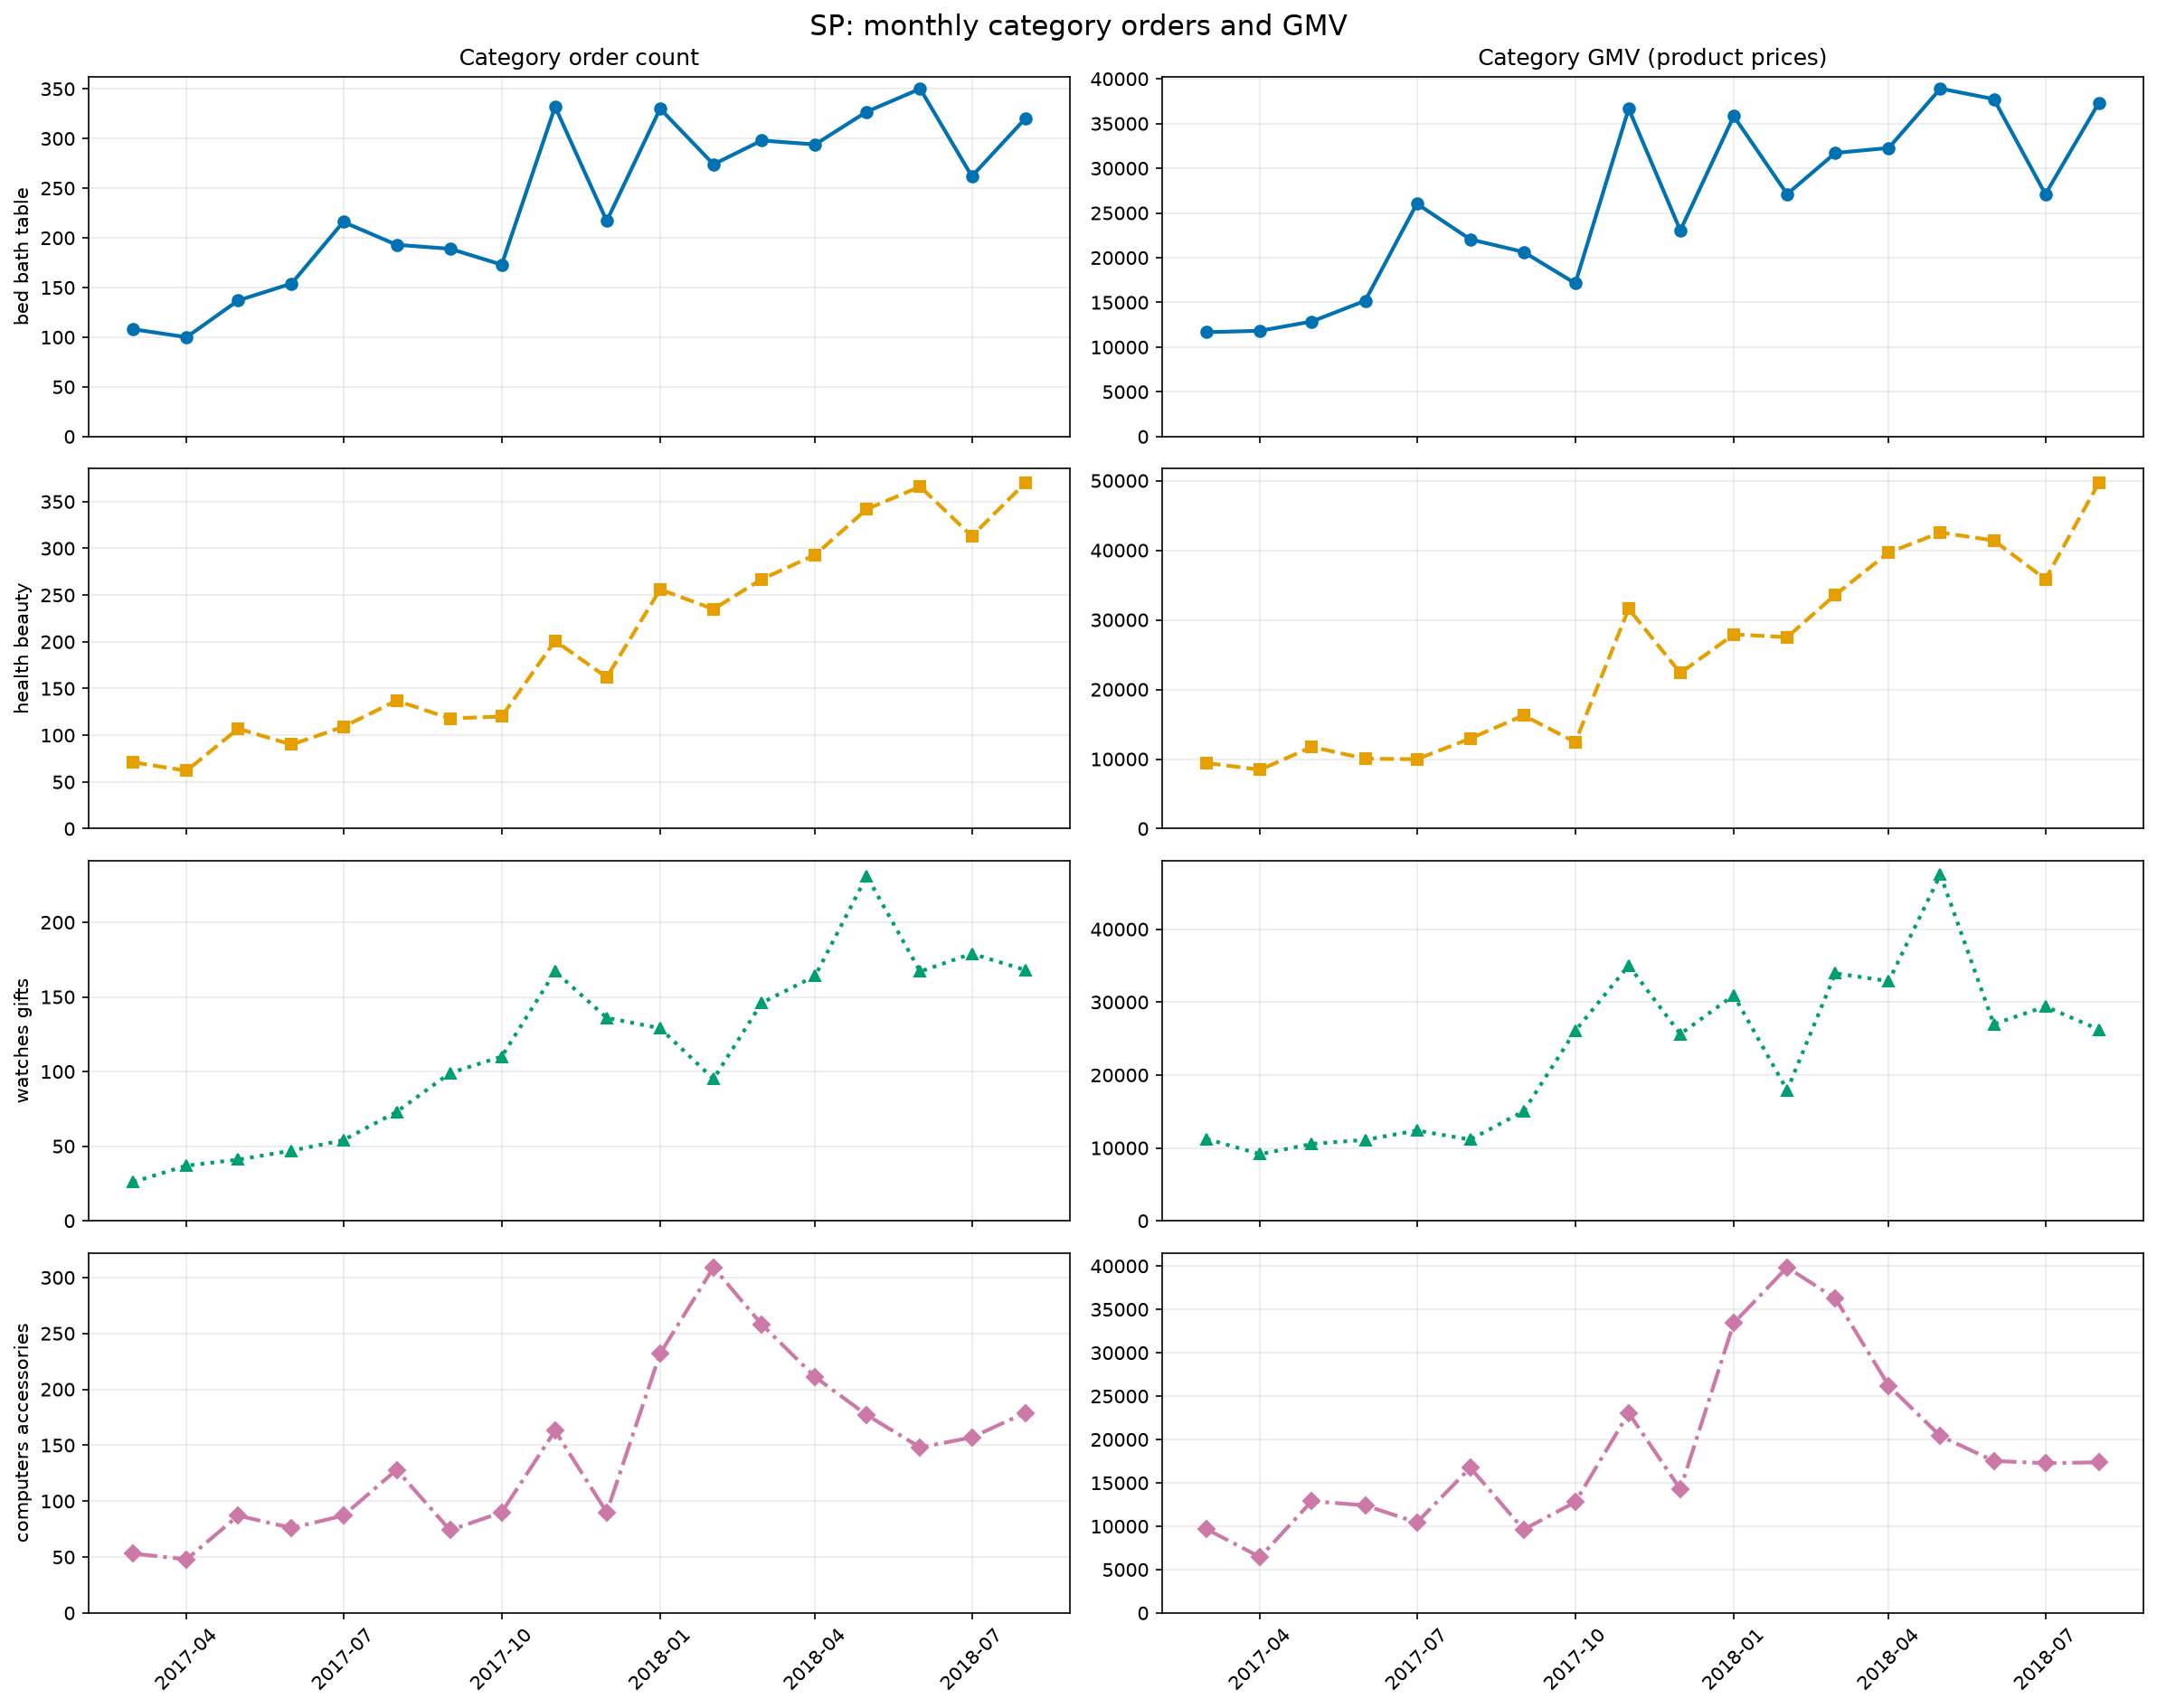

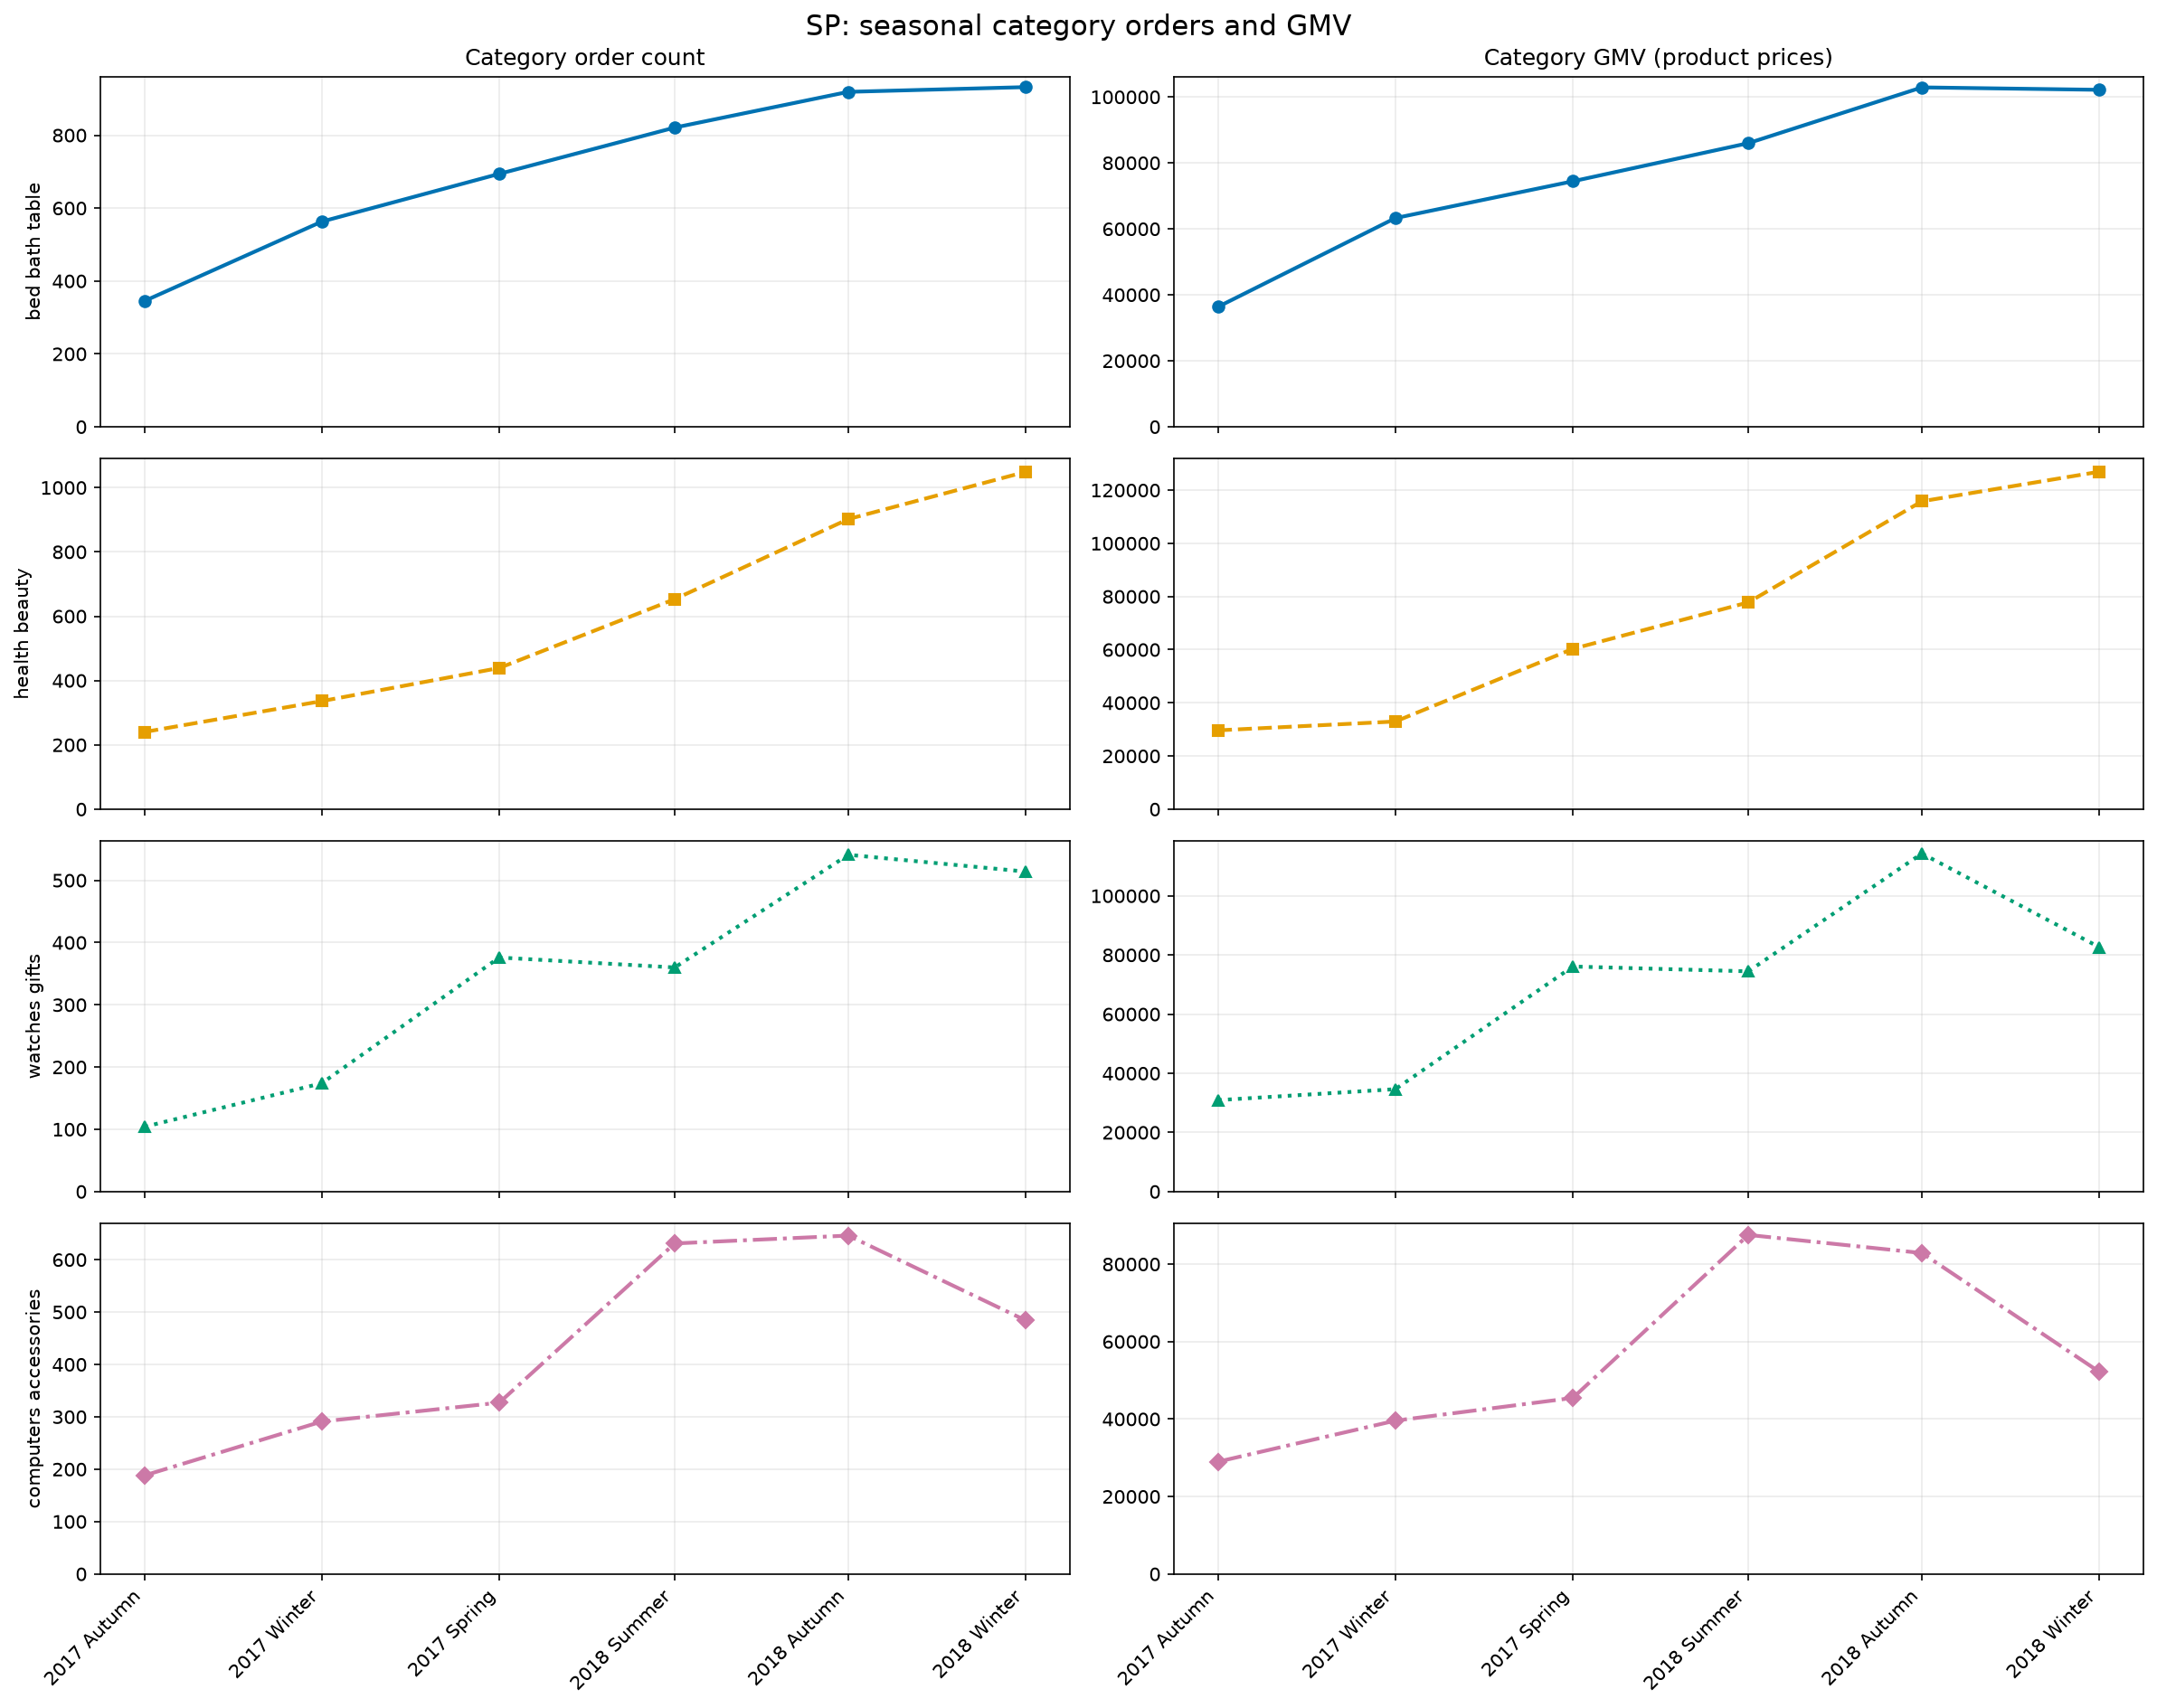

In [9]:
# 既に作った月別・季節別の表を使い、絶対数を別の縦軸で描く。
# 月別は2017年3月～2018年8月、季節別は同期間の3か月合計。
sp_monthly_absolute_figure = plot_sp_category_orders_and_gmv(
    monthly_plot, "period_start", focus_categories,
    "SP: monthly category orders and GMV",
    IMAGE_DIR / "SP_Category_Order_Count_and_GMV_Monthly.png",
)
sp_seasonal_absolute_figure = plot_sp_category_orders_and_gmv(
    seasonal_plot, "season_start", focus_categories,
    "SP: seasonal category orders and GMV",
    IMAGE_DIR / "SP_Category_Order_Count_and_GMV_Seasonal.png",
)


### 同じ冬を比べ、GMVの変化を2つの要素に分ける

カテゴリGMVは「カテゴリ注文数 × カテゴリ注文あたりGMV」に等しい。2017年冬を基準にすると、次の式で2018年冬との差を過不足なく分けられる。

`GMVの差 = (2018年の注文数 - 2017年の注文数) × 2017年の注文あたりGMV + 2018年の注文数 × (2018年の注文あたりGMV - 2017年の注文あたりGMV)`

前半は2017年の注文あたりGMVを固定したときの**件数の変化分**、後半は2018年の件数を固定したときの**注文あたりGMVの変化分**。これは数値の分解であり、注文増の原因や販促の効果を示すものではない。


In [10]:
# 先ほど確認したSP州の2017年冬と2018年冬の4カテゴリを横に並べる。
comparison_columns = [
    "product_category", "category_order_count", "category_gmv",
    "category_gmv_per_category_order",
]
winter_2017 = sp_winter.loc[
    sp_winter["season_label"] == "2017 Winter", comparison_columns
].rename(columns={
    "category_order_count": "orders_2017",
    "category_gmv": "gmv_2017",
    "category_gmv_per_category_order": "gmv_per_order_2017",
})
winter_2018 = sp_winter.loc[
    sp_winter["season_label"] == "2018 Winter", comparison_columns
].rename(columns={
    "category_order_count": "orders_2018",
    "category_gmv": "gmv_2018",
    "category_gmv_per_category_order": "gmv_per_order_2018",
})
sp_winter_change = winter_2017.merge(
    winter_2018, on="product_category", validate="one_to_one"
)
sp_winter_change["order_change"] = (
    sp_winter_change["orders_2018"] - sp_winter_change["orders_2017"]
)
sp_winter_change["gmv_change"] = (
    sp_winter_change["gmv_2018"] - sp_winter_change["gmv_2017"]
)
sp_winter_change["order_count_component"] = (
    sp_winter_change["order_change"] * sp_winter_change["gmv_per_order_2017"]
)
sp_winter_change["gmv_per_order_component"] = (
    sp_winter_change["orders_2018"]
    * (sp_winter_change["gmv_per_order_2018"]
       - sp_winter_change["gmv_per_order_2017"])
)
sp_winter_change["reconciliation_difference"] = (
    sp_winter_change["gmv_change"]
    - sp_winter_change["order_count_component"]
    - sp_winter_change["gmv_per_order_component"]
)
display(sp_winter_change.sort_values("product_category").round(2))
print("分解後の差の最大絶対値:", sp_winter_change["reconciliation_difference"].abs().max())


,product_category,orders_2017,gmv_2017,gmv_per_order_2017,orders_2018,gmv_2018,gmv_per_order_2018,order_change,gmv_change,order_count_component,gmv_per_order_component,reconciliation_difference
0,bed_bath_table,563,63273.27,112.39,932,102152.61,109.61,369,38879.34,41470.40,-2591.06,-0.0
1,computers_accessories,291,39582.72,136.02,484,52168.36,107.79,193,12585.64,26252.46,-13666.82,0.0
2,health_beauty,336,32975.36,98.14,1049,126922.31,120.99,713,93946.95,69974.50,23972.45,0.0
3,watches_gifts,174,34627.62,199.01,514,82620.28,160.74,340,47992.66,67663.17,-19670.51,-0.0


分解後の差の最大絶対値: 1.4551915228366852e-11


### 読み取れることと次の問い

- 月別では`bed_bath_table`の2018年5月→6月に注文数が327→350件へ増えた一方、カテゴリGMVは38,908.24→37,740.78へ減った。注文数とGMVが常に同じ方向に動くわけではない。
- `health_beauty`は2017年冬から2018年冬にカテゴリ注文数が336→1,049件、カテゴリGMVが32,975.36→126,922.31となった。GMV増加額93,946.95を、件数の変化分69,974.50とカテゴリ注文あたりGMVの変化分23,972.45に分けられる。
- `bed_bath_table`、`computers_accessories`、`watches_gifts`も注文数とGMVは増えたが、カテゴリ注文あたりGMVは低下した。そのためGMV増加額は、2017年の注文あたりGMVで評価した件数の増加分より小さい。
- 4カテゴリの注文数を足しても州全体の注文数にはならない。GMVの変化を施策の増分売上や利益とみなすこともできない。月別の上下は1年半の観察であり、季節性の断定には年数が不足する。
- 保存済みの`sp_product_mix_winter_comparison.csv`は、次に**カテゴリ内の商品ID別構成**を見るためのデータ。この段階では注文数とカテゴリGMVの確認にとどめ、商品構成の解釈は別に行う。


## 図の次に確認すること

図で差や変化が見つかっても、季節性や施策効果とすぐに判断しない。各点のカテゴリ注文数と州全体の注文数、商品・販売者の構成、年ごとの再現性を確認する。PB・APは少数注文による振れが大きいため、SPへの転用可能性も別途検討する。販促費・原価がない限り、利益の増加は計算できない。
